In [2]:
params <- list(
    i_counts_tab="results/ASVs_counts.tsv",
    i_norm_counts_tab="results/ASVs_counts_normalized.tsv",
    i_distances_matrix="results/ASVs_euclidean_distance.tsv",
    i_taxa_table="results/ASVs_taxa.tsv",
    i_reads_loss="results/reads_loss_summary.tsv",
    all_meta="resources/metadata/all_meta.csv"
)

In [3]:
library(phyloseq)
library(ggplot2)
library(vegan)
library(gt)
library(dplyr)
library(tibble)
library(dendextend)
library(ggpubr)
library(patchwork)
source("workflow/scripts/plots/dendrogram.R")

Loading required package: permute


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Registered S3 method overwritten by 'dendextend':
  method     from 
  rev.hclust vegan


---------------------
Welcome to dendextend version 1.19.1
Type citation('dendextend') for how to cite the package.

Type browseVignettes(package = 'dendextend') for the package vignette.
The github page is: https://github.com/talgalili/dendextend/

Suggestions and bug-reports can be submitted at: https://github.com/talgalili/dendextend/issues
You may ask questions at stackoverflow, use the r and dendextend tags: 
	 https://stackoverflow.com/questions/tagged/dendextend

	To suppress this message use:  suppressPackageStartupMessages(library(dendextend))
---------------------



Attaching package: ‘dendextend’


The following object is masked from ‘package:permute’:



In [4]:
norm_counts_tab <- read.csv(params$i_norm_counts_tab,sep = "\t", row.names='X')
counts_tab <- read.csv(params$i_counts_tab,sep = "\t", row.names='X')

samples_info <- read.csv(params$all_meta, row.names='Run')[colnames(norm_counts_tab), ]
euc_dist_all <- as.dist(as.matrix(read.csv(
    params$i_distances_matrix, 
    sep='\t', 
    header=T,
    row.names=1
)))
taxa_table <- as.matrix(read.csv(params$i_taxa_table, sep = "\t", row.names=1))


counts_phy <- otu_table(norm_counts_tab, taxa_are_rows = T)
samples_info_phy <- sample_data(samples_info)
taxa_table_phy <- tax_table(taxa_table)

phy_norm <- phyloseq(counts_phy, samples_info_phy, taxa_table_phy)
phy_raw <- phyloseq(counts_phy, samples_info_phy, taxa_table_phy)

meta <- data.frame(sample_data(phy_norm))
predictors <- c('depr_or_control', 'batch', 'd_sex', 'd_age_hc')
predictors <- predictors[meta[predictors] |> sapply(function(x) length(unique(x))) > 1]
rhs <- paste(predictors, collapse = " + ")

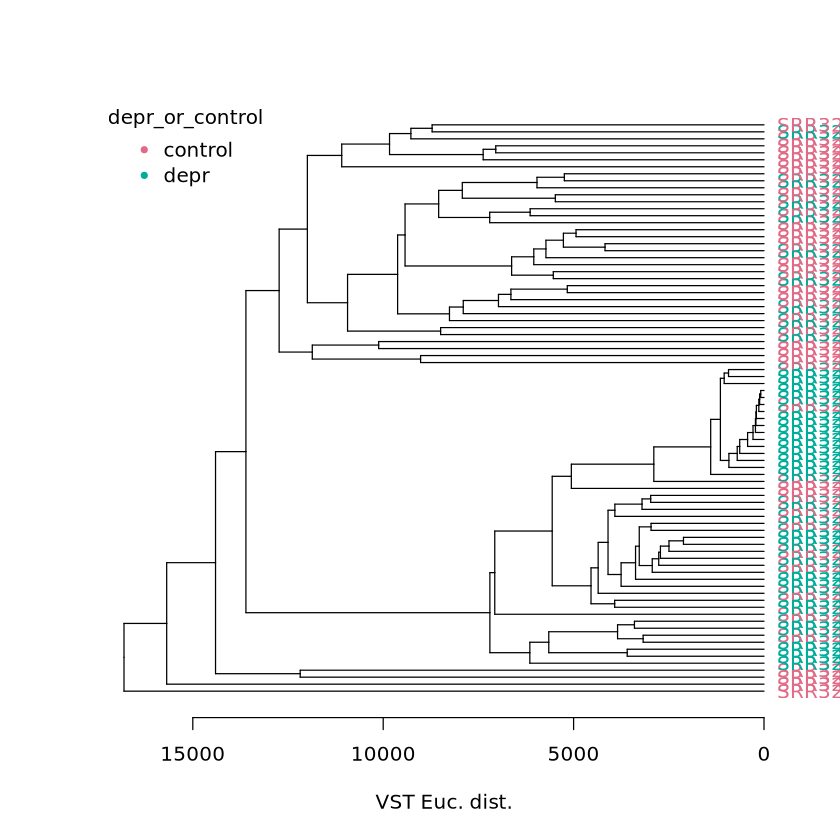

In [5]:
plot_dendrogram(euc_dist_all, phy_norm, depr_or_control)

# Beta dispersion

Plod ordination plot by ASV

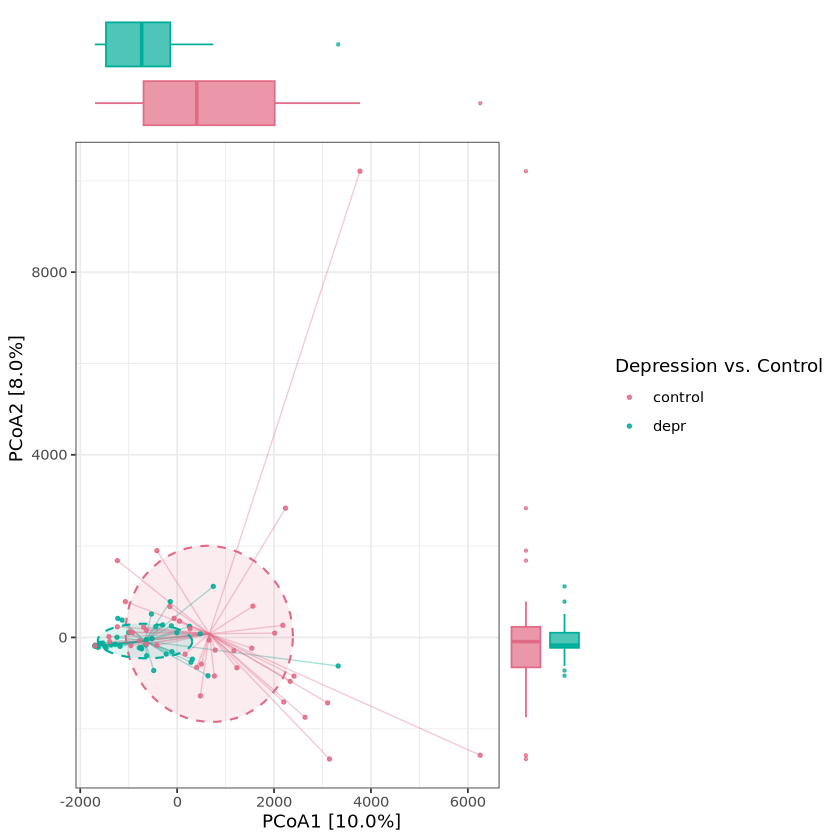

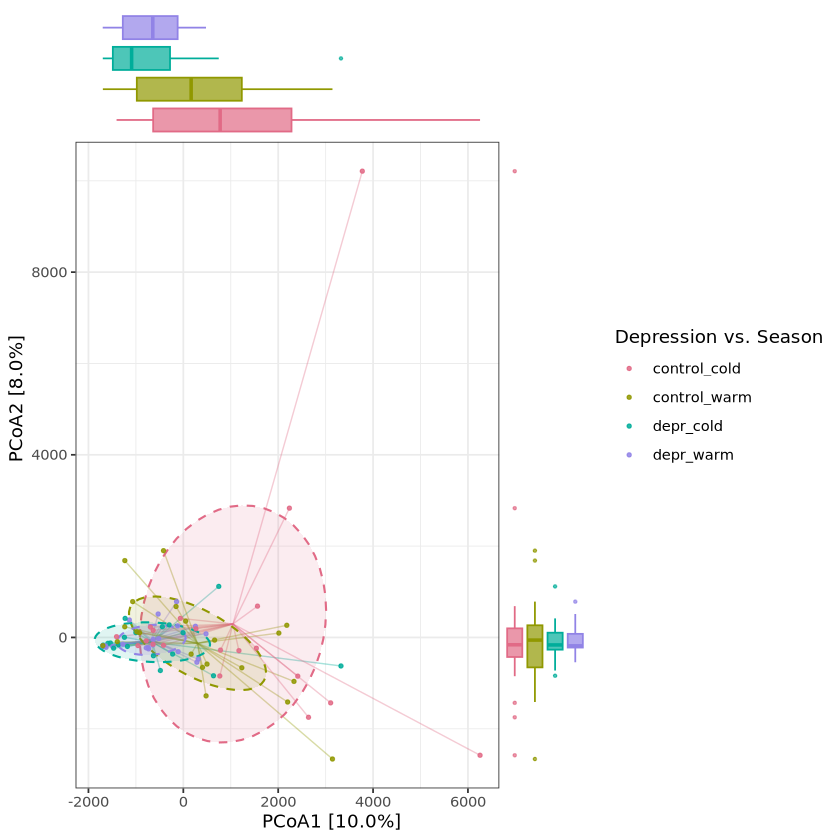

In [6]:
source("workflow/scripts/plots/pcoa.R")
ord_res <- plot_pcoa(phy_norm, euc_dist_all, depr_or_control, legend_title="Depression vs. Control")
pcoa <- ord_res$pcoa
plot_pcoa(phy_norm, euc_dist_all, paste(depr_or_control, season, sep="_"), legend_title="Depression vs. Season")

## Analyze extreme samples from ordination

In [7]:
scores <- as.data.frame(pcoa$points)
d2 <- mahalanobis(
    scores,
    colMeans(scores),
    cov(scores)
)
outliers <- which(
    d2 > qchisq(0.975, df = 2)
)

Too few points to calculate an ellipse


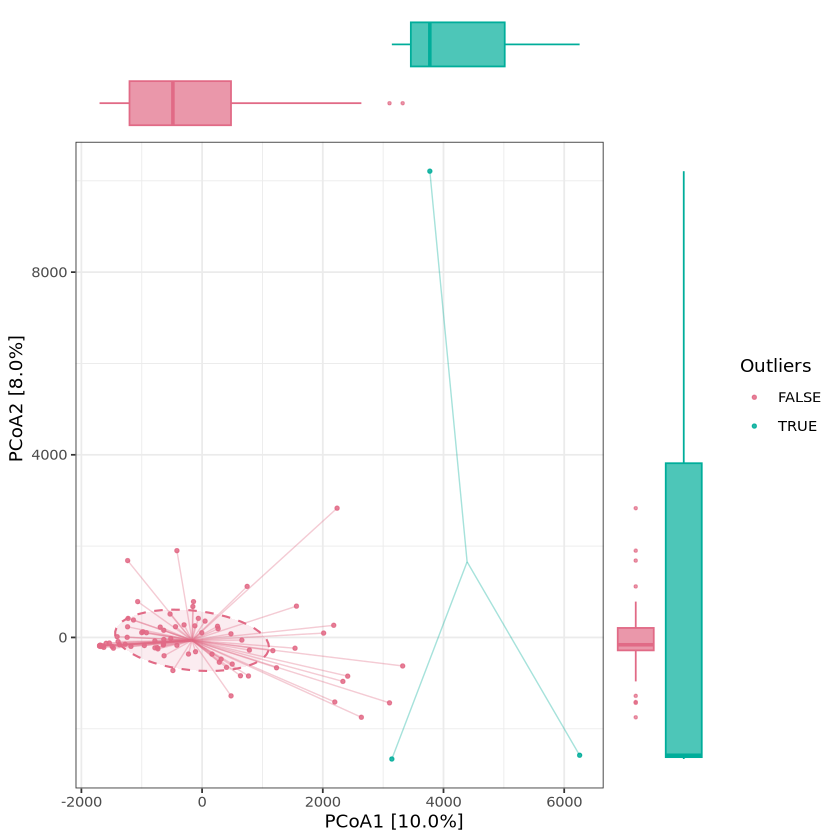

In [8]:
plot_pcoa(phy_norm, euc_dist_all, rownames(sample_data(phy_norm)) %in% names(outliers), legend_title="Outliers")

Firstly, check metadata for extreme samples

In [9]:
names(outliers)
sample_data(phy_norm)[
    names(outliers),
    c(
        'd_sex',
        'd_age_hc', 
        'bd_education3_vs',
        'depr_or_control', 
        'season'
        # 'match_group'
    )
]

[1] "SRR32393576" "SRR32393725" "SRR32393660"

,d_sex,d_age_hc,bd_education3_vs,depr_or_control,season
,<chr>,<dbl>,<chr>,<chr>,<chr>
SRR32393576,female,68.11499,Secondary,control,cold
SRR32393725,female,62.16564,Secondary,control,warm
SRR32393660,female,54.59822,Higher,control,cold


Ok... nothing special in these metadata. Lets check sequencing metrics

In [10]:
reads_loss <- read.csv('results/reads_loss_summary.tsv', sep="\t")
reads_loss$group <- factor(ifelse(rownames(reads_loss) %in% names(outliers), 'extreme', 'regular'), levels = c('regular', 'extreme'))

In [11]:
library(tidyverse)

reads_loss_plot <- reads_loss |>
    rownames_to_column("sample") |>
    transmute(
        sample,
        group,
        Filtered = filtered / input,
        Merged = merged / input,
        Nochim = nochim / input
    ) |>
    pivot_longer(
        -c(sample, group),
        names_to = "stage",
        values_to = "retention"
    )

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ forcats   1.0.1     ✔ readr     2.2.0
✔ lubridate 1.9.5     ✔ stringr   1.6.0
✔ purrr     1.2.2     ✔ tidyr     1.3.2
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter()      masks stats::filter()
✖ purrr::flatten()     masks rlang::flatten()
✖ purrr::flatten_chr() masks rlang::flatten_chr()
✖ purrr::flatten_dbl() masks rlang::flatten_dbl()
✖ purrr::flatten_int() masks rlang::flatten_int()
✖ purrr::flatten_lgl() masks rlang::flatten_lgl()
✖ purrr::flatten_raw() masks rlang::flatten_raw()
✖ purrr::invoke()      masks rlang::invoke()
✖ dplyr::lag()         masks stats::lag()
✖ purrr::splice()      masks rlang::splice()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


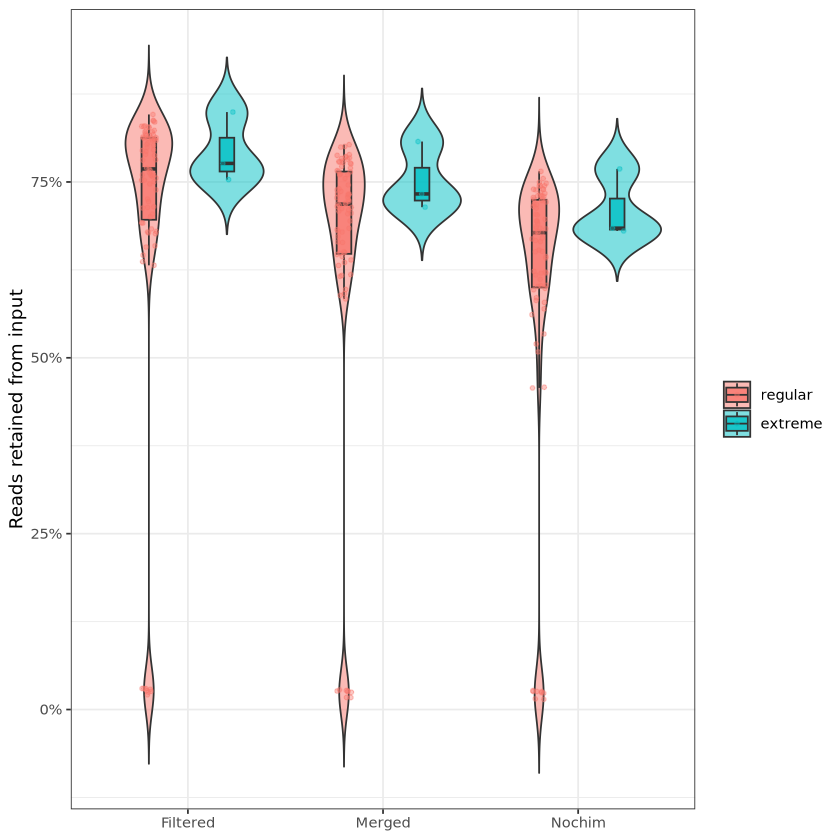

In [12]:
ggplot(
    reads_loss_plot,
    aes(
        x = stage,
        y = retention,
        fill = group
    )
) +
    geom_violin(
        position = position_dodge(width = 0.8),
        trim = FALSE,
        alpha = 0.5
    ) +
    geom_boxplot(
        width = 0.15,
        position = position_dodge(width = 0.8),
        outlier.shape = NA,
        alpha = 0.8
    ) +
    geom_jitter(
        aes(color = group),
        position = position_jitterdodge(
            jitter.width = 0.15,
            dodge.width = 0.8
        ),
        alpha = 0.4,
        size = 1
    ) +
    scale_y_continuous(
        labels = scales::percent_format(accuracy = 1)
    ) +
    labs(
        x = NULL,
        y = "Reads retained from input",
        fill = NULL,
        color = NULL
    ) +
    theme_bw()

Trend of reads loss kinda the same for regular reads and extreme

Check number of taxa 

In [13]:
ntaxa(phy_norm)

extreme_phy <- prune_samples(names(outliers), phy_norm)
extreme_phy <- prune_taxa(taxa_sums(extreme_phy) > 0, extreme_phy)
ntaxa(extreme_phy)

[1] 5269

[1] 1620

In [14]:
taxa_per_sample <- function(phy) as.data.frame(rowSums(t(otu_table(phy)) > 0))
'All samples'
summary(taxa_per_sample(phy_norm))
'Extreme samples'
summary(taxa_per_sample(extreme_phy))

[1] "All samples"

 rowSums(t(otu_table(phy)) > 0)
 Min.   : 159.0                
 1st Qu.: 477.2                
 Median : 612.5                
 Mean   : 606.8                
 3rd Qu.: 754.8                
 Max.   :1160.0                

[1] "Extreme samples"

 rowSums(t(otu_table(phy)) > 0)
 Min.   : 522.0                
 1st Qu.: 567.0                
 Median : 612.0                
 Mean   : 757.3                
 3rd Qu.: 875.0                
 Max.   :1138.0                

Looks like average amount of taxa a little bigger for extreme samples 

Ok. Lest try plot ordination without outliers

In [15]:
phy_1 <- subset_samples(phy_norm, !(rownames(sample_data(phy_norm)) %in% names(outliers)))
nsamples(phy_1)

[1] 79

## Betadisper

In [16]:
anova(betadisper(euc_dist_all, sample_data(phy_norm)$depr_or_control), by='margin')

,Df,Sum Sq,Mean Sq,F value,Pr(>F)
,<int>,<dbl>,<dbl>,<dbl>,<dbl>
Groups,1,147095404,147095404,28.5882,8.267523e-07
Residuals,80,411625444,5145318,NA,NA


So depression and control samples have heterogeneous dispersions, which means I cannot truly trust permanova test on whole set. But amount of samples are the same for depression and control sets. So premanova still valid choice

In [17]:
betadisper(euc_dist_all, sample_data(phy_norm)$depr_or_control)$group.distances

control     depr 
5381.030 2702.339


Spread of control samples twice bigger then depression set.

In [25]:
form_string <- paste("euc_dist_all", "~", rhs)
f <- as.formula(form_string)
adonis2(f, meta, by = 'margin', permutations = 999)

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
depr_or_control,1,52870613,0.02768639,2.284239,0.001
d_sex,1,25873794,0.01354915,1.117860,0.266
d_age_hc,1,24388982,0.01277161,1.053710,0.362
Residual,78,1805374538,0.94540812,NA,NA
Total,81,1909624526,1.00000000,NA,NA


Differences of dispersion are illustrated by different size of groups ellipses on PCoA plot. And differences of centroids - by gap between ellipses. 

## Interim conclusions: Beta

__Significant differences in gut microbiome composition were detected between patients with depression and the control group. These differences are associated with variations in the mean community structure and increased microbial community dispersion in depressed patients.__

Ok. Lets tets season depression

In [19]:
paste(sample_data(phy_norm)$depr_or_control, sample_data(phy_norm)$season, sep="_") |> table()


control_cold control_warm    depr_cold    depr_warm 
          20           21           20           21 

In [20]:
anova(betadisper(euc_dist_all, paste(sample_data(phy_norm)$depr_or_control, sample_data(phy_norm)$season, sep="_")), by='margin')

,Df,Sum Sq,Mean Sq,F value,Pr(>F)
,<int>,<dbl>,<dbl>,<dbl>,<dbl>
Groups,3,144549121,48183040,9.367748,2.324204e-05
Residuals,78,401193216,5143503,NA,NA


In [26]:
form_string <- paste("euc_dist_all", "~", "season * ", rhs)
f <- as.formula(form_string)
adonis2(f, meta, permutations = 999, by = 'margin')

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
d_sex,1,26977355,0.01412705,1.1633548,0.239
d_age_hc,1,24184362,0.01266446,1.0429115,0.396
season:depr_or_control,1,21547966,0.01128388,0.9292212,0.644
Residual,76,1762384993,0.92289608,NA,NA
Total,81,1909624526,1.00000000,NA,NA


So seams there are no associations between microbiome and seasonal depression

# Alpha

## Rarecurve

In [ ]:
library(rlang)
plot_rarecurve <- function(ps, color_condition) {
    group_condition <- rlang::enquo(color_condition)
    group <- rlang::eval_tidy(
        group_condition,
        data=sample_data(ps)
    )
    group <- factor(group)
    group_levels <- levels(group)
    group_colors <- setNames(hcl.colors(length(group_levels), palette = "Dark 3"), group_levels)
    otu_matrix <- t(as.data.frame(otu_table(ps)))
    rarecurve(otu_matrix, step=100, lwd=2, ylab="ASVs", label=FALSE, col=group_colors[group])
    legend("bottomright", legend=levels(group), col=group_colors, lwd=2, bty="n")
    abline(v=(min(rowSums(otu_matrix))))
}

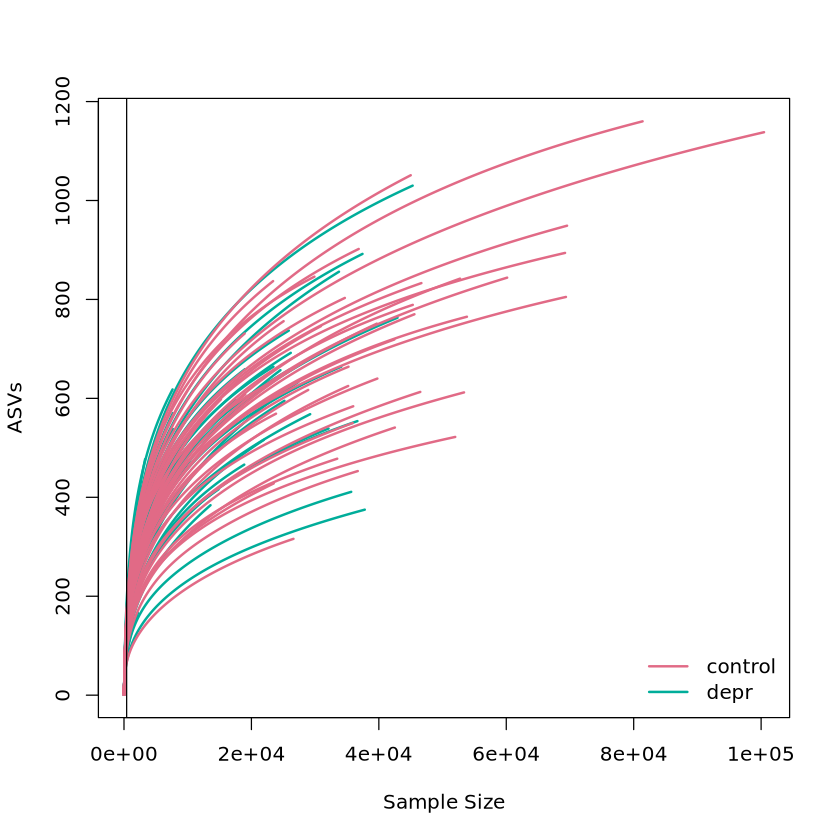

In [ ]:
plot_rarecurve(phy_raw, depr_or_control)

Looks like average internal diversity are the same fot most of samples. And it's contradicts with previous conclusion? that dispersion is bigger for depression set. 

Also there are some samples with extra small sample size. 

In [ ]:
sample_size <- otu_table(phy_raw) |> 
    as.data.frame() |>
    t() |>
    rowSums()
    
small_samples <- subset(sample_data(phy_raw), sample_size < 1e4, select = c('depr_or_control'))

In [ ]:
paste0(rownames(small_samples[small_samples == "control"]), collapse = "\", \"")

[1] "SRR32393512"

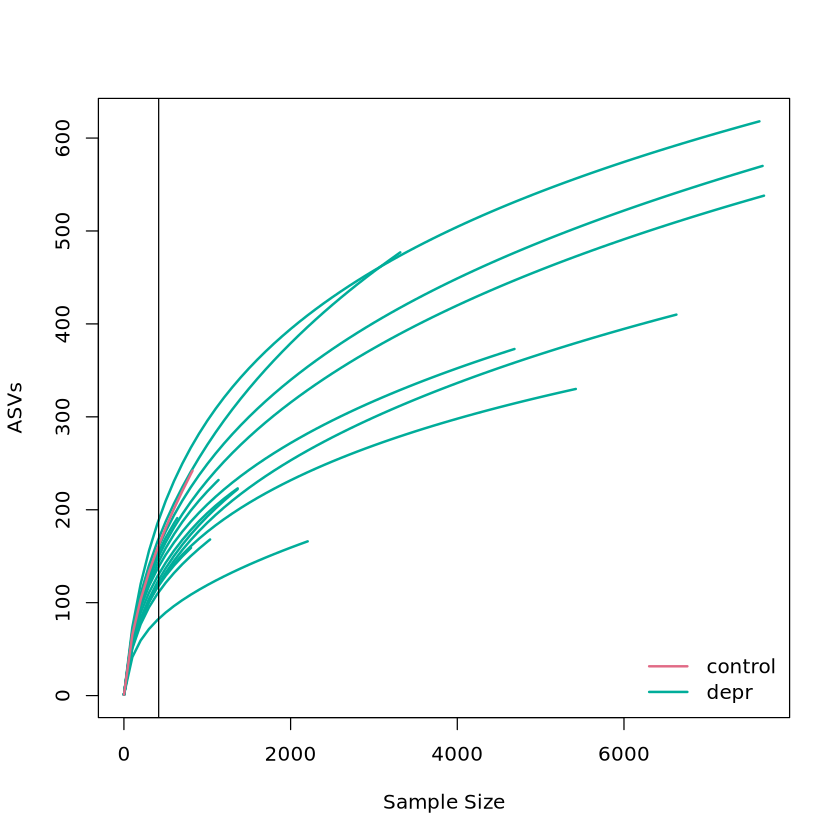

In [ ]:
plot_rarecurve(prune_samples(row.names(small_samples), phy_raw), depr_or_control)

Ok. Lest see reads loss plots..

[1] "Extreme samples"

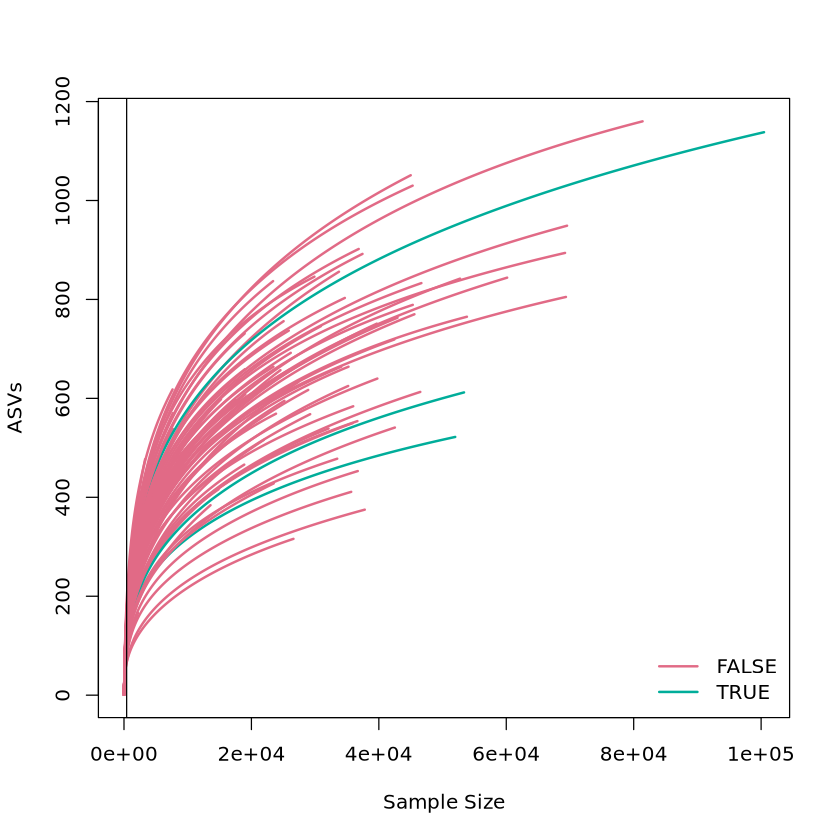

In [ ]:
'Extreme samples'
plot_rarecurve(phy_raw, rownames(sample_data(phy_norm)) %in% names(outliers))

## Chao1, Shannon, Simpson

In [ ]:
phy_raw_no_zero_taxa <- prune_taxa(taxa_sums(phy_raw) > 0, phy_raw)

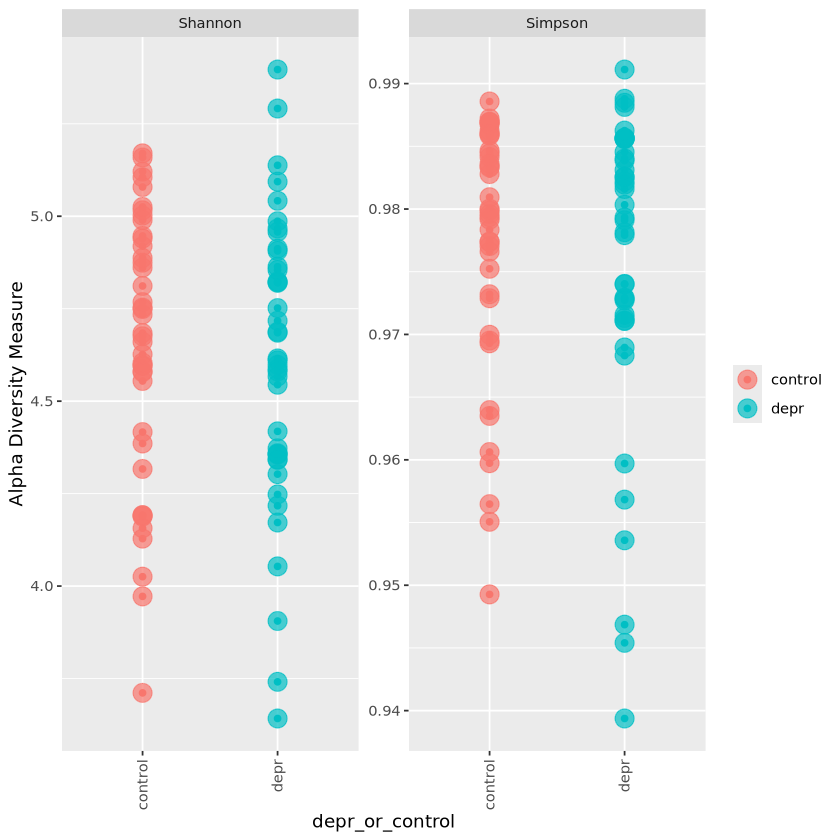

In [ ]:
# Alpha diversity plot Depression
plot_richness(phy_raw_no_zero_taxa, x="depr_or_control", color="depr_or_control", measures = c("Shannon", "Simpson")) +
    theme(
        legend.title = element_blank(),
        axis.text.x = element_text(angle = 90, vjust = 0.5, hjust = 1),
    ) +
    geom_point(size=5, alpha=0.7)

In [ ]:
alpha <- estimate_richness(phy_raw_no_zero_taxa, measures = c("Shannon", "Simpson", "Chao1"))

In [ ]:
cbind(sample_data(phy_raw), alpha)[['depr_or_control']] |> unique()

[1] "depr"    "control"

In [ ]:
plot_alpha_violins <- function(df, x, y, plot_file = NULL) {
    y_metrics <- if (length(y) == 1) y else y
    
    build_single_plot <- function(metric) {
        groups <- unique(df[[x]])
        comp <- combn(groups, 2, simplify = F)
        
        ggviolin(
            df, 
            x = x, 
            y = metric, 
            fill = x, 
            palette = hcl.colors(length(groups), palette = "Dark 3"), 
            add = "boxplot"
        ) +
        stat_compare_means(
            method = "t.test", 
            comparisons = comp, 
            label.y.npc = 0.95
        ) +
        labs(title = metric) +
        theme(plot.title = element_text(hjust = 0.5, size = 12, face = "bold"))
    }
    
    plots <- lapply(y_metrics, build_single_plot)
    
    p <- if (length(plots) == 1) plots[[1]] else wrap_plots(plots, nrow = 1)
    
    plot(p)

    if (!is.null(plot_file) && plot_file != "") {
        width <- if (length(plots) == 1) 12 else 5 * length(plots)
        height <- if (length(plots) == 1) 12 else 5
        ggsave(plot_file, plot = p, width = width, height = height, dpi = 300)
        cat(sprintf("\nPlot saved to: %s\n", plot_file))
    }
}


Plot saved to: results/figures/alpha.png


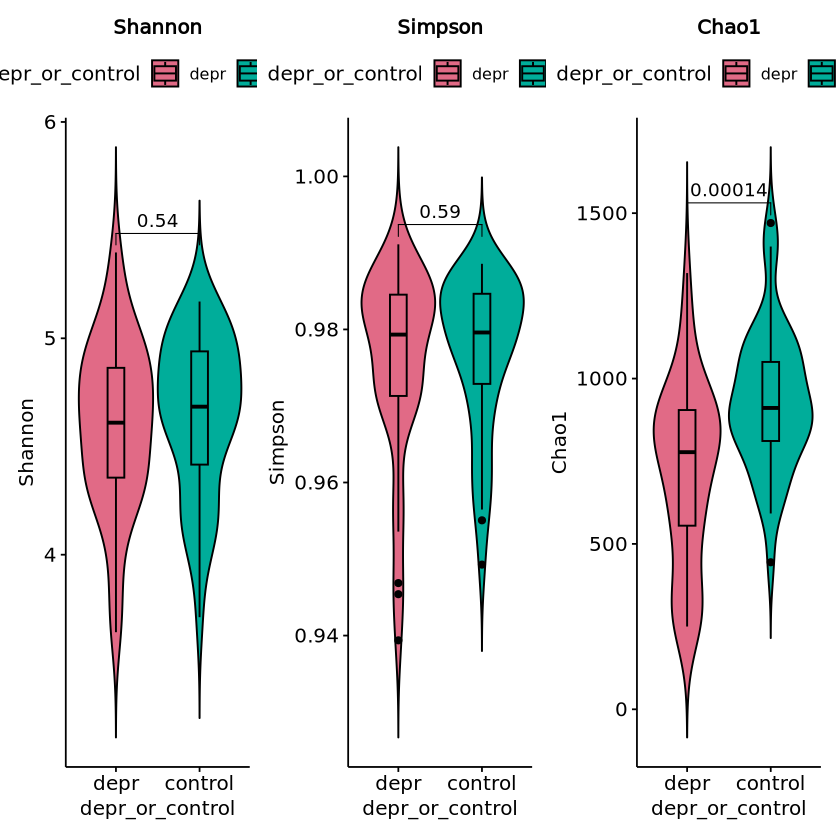

In [ ]:
plot_alpha_violins(cbind(sample_data(phy_raw), alpha), "depr_or_control",  c("Shannon", "Simpson", "Chao1"), 'results/figures/alpha.png')